In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import MultiComparison
from scipy import stats

In [86]:
# config
# as environment: ../../candidate-profling/cand-prof-env.yml
PROTEIN_NAME = "vcam1"
PROTEIN_NAME_UPPER = PROTEIN_NAME.upper()
DATA = f"data/crispr-cas9-{PROTEIN_NAME}-hippo-intensity.xlsx"

In [87]:
df = pd.read_excel(DATA)
df.head(10)

,Brain,condition,raw_mean_intensity
0,4.0,LacZ-gRNA,13372.568
1,4.0,VCAM1-gRNA,8171.255
2,4.0,background,3920.133
3,4.2,LacZ-gRNA,18017.003
4,4.2,VCAM1-gRNA,8062.353
5,4.2,background,3973.207
6,5.0,LacZ-gRNA,11140.019
7,5.0,VCAM1-gRNA,6026.372
8,5.0,background,2988.400
9,7.0,LacZ-gRNA,15248.339


### Data transformation

In [88]:
# Subtract background per animal
bg = df[df['condition'] == 'background'].set_index('Brain')['raw_mean_intensity']

wide = df[df['condition'] != 'background'].pivot(index='Brain', columns='condition', values='raw_mean_intensity')
wide['background'] = bg
wide['LacZ_corrected'] = wide['LacZ-gRNA'] - wide['background']
wide[f"{PROTEIN_NAME_UPPER}_corrected"] = wide[f"{PROTEIN_NAME_UPPER}-gRNA"] - wide['background']

# relative expression, normalized to mean of LacZ controls
wide['LacZ_relative'] = wide['LacZ_corrected'] / wide['LacZ_corrected'].mean()
wide[f"{PROTEIN_NAME_UPPER}_relative"] = wide[f"{PROTEIN_NAME_UPPER}_corrected"] / wide['LacZ_corrected'].mean()

wide

condition,LacZ-gRNA,VCAM1-gRNA,background,LacZ_corrected,VCAM1_corrected,LacZ_relative,VCAM1_relative
Brain,,,,,,,
4.0,13372.568,8171.255,3920.133,9452.435,4251.122,0.877035,0.394436
4.2,18017.003,8062.353,3973.207,14043.796,4089.146,1.303039,0.379407
5.0,11140.019,6026.372,2988.400,8151.619,3037.972,0.756340,0.281875
7.0,15248.339,7530.512,3785.302,11463.037,3745.210,1.063586,0.347496


### Plotting the data

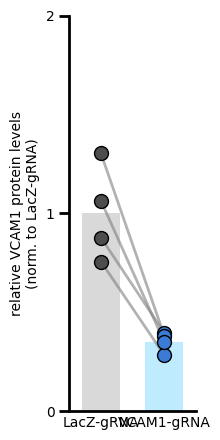

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# --- data prep (from your `wide` dataframe) ---
lacz = wide['LacZ_relative'].values
protein_of_interest = wide[f"{PROTEIN_NAME_UPPER}_relative"].values

groups = [lacz, protein_of_interest]
labels = ['LacZ-gRNA', f"{PROTEIN_NAME_UPPER}-gRNA"]

if PROTEIN_NAME == "vcam1":
    dot_colors = ['#4d4d4d', '#3a7bd5']  
    colors = ['#d9d9d9', '#BFEBFF']
else:
    dot_colors = ['#4d4d4d', '#E28D21']
    colors = ['#d9d9d9', '#F8E2C7']     # dot color per group
x_pos = [0, 1]

fig, ax = plt.subplots(figsize=(2.2, 4.5))

# bars = group means
ax.bar(x_pos[0], np.mean(lacz), width=0.6, color=colors[0], zorder=1)
ax.bar(x_pos[1], np.mean(protein_of_interest), width=0.6, color=colors[1], zorder=1)

# connecting lines (straight, no jitter)
for y0, y1 in zip(lacz, protein_of_interest):
    ax.plot([x_pos[0], x_pos[1]], [y0, y1], color='gray', linewidth=2, alpha=0.6, zorder=2)

# dots
ax.scatter(np.full(len(lacz), x_pos[0]), lacz, color=dot_colors[0], s=100, zorder=3,
           edgecolor='black', linewidth=1)
ax.scatter(np.full(len(protein_of_interest), x_pos[1]), protein_of_interest, color=dot_colors[1], s=100, zorder=3,
           edgecolor='black', linewidth=1)

# --- formatting ---
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel('relative VCAM1 protein levels\n(norm. to LacZ-gRNA)')
ax.set_ylim(0, 2)
ax.set_yticks(np.arange(0, 2.01, 1))
ax.set_xlim(-0.5, 1.5)
ax.spines[['top', 'right']].set_visible(False)

# thicker axis spines and ticks
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='x', length=0, width=2)
ax.tick_params(axis='y', length=7, width=2)

plt.tight_layout()
plt.show()

fig.savefig(
    f"{PROTEIN_NAME}_KO_analysis.svg",
    format="svg",
    bbox_inches="tight"
)

### Statistical test: paired t-test

In [90]:
t_stat, p_val = stats.ttest_rel(wide['LacZ_corrected'], wide[f"{PROTEIN_NAME_UPPER}_corrected"])
print(f"paired t-test: t={t_stat:.3f}, p={p_val:.4g}")

paired t-test: t=6.052, p=0.00905
